In [1]:
import pandas as pd

df = pd.read_csv("Comprehensive Gamer Preference Survey (Responses) - Form Responses 1.csv")

df.columns = [
    'timestamp', 'platform', 'hours_played', 'game_type', 'play_frequency',
    'addiction_level', 'academic_impact', 'download_method', 'play_with_friends',
    'competitive_gaming', 'in_game_purchases', 'time_of_day', 'play_reason',
    'sleep_impact', 'stress_impact', 'made_online_friends'
]

df['sleep_impact'] = df['sleep_impact'].str.extract('(\d+)').astype(float)
df['stress_impact'] = df['stress_impact'].str.extract('(\d+)').astype(float)

df['addiction_level'].fillna(df['addiction_level'].median(), inplace=True)
df['sleep_impact'].fillna(df['sleep_impact'].median(), inplace=True)
df['stress_impact'].fillna(df['stress_impact'].median(), inplace=True)

for col in ['academic_impact', 'download_method', 'competitive_gaming', 'in_game_purchases', 'time_of_day']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Data Cleaning Complete. Missing values:")
print(df.isnull().sum())

Data Cleaning Complete. Missing values:
timestamp              0
platform               0
hours_played           0
game_type              0
play_frequency         0
addiction_level        0
academic_impact        0
download_method        0
play_with_friends      0
competitive_gaming     0
in_game_purchases      0
time_of_day            0
play_reason            0
sleep_impact           0
stress_impact          0
made_online_friends    0
dtype: int64


C:\Users\pc-lenovo\AppData\Local\Temp\ipykernel_13804\1400051044.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['addiction_level'].fillna(df['addiction_level'].median(), inplace=True)
C:\Users\pc-lenovo\AppData\Local\Temp\ipykernel_13804\1400051044.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

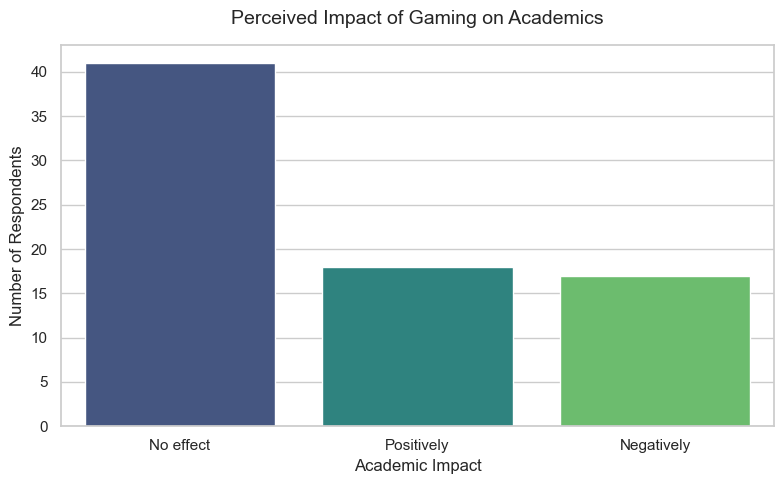

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
academic_counts = df['academic_impact'].value_counts().sort_values(ascending=False)
sns.barplot(x=academic_counts.index, y=academic_counts.values, hue=academic_counts.index, palette="viridis", dodge=False)
plt.legend([],[], frameon=False) 
plt.title("Perceived Impact of Gaming on Academics", fontsize=14, pad=15)
plt.xlabel("Academic Impact", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.tight_layout()
plt.show()



Insight: The majority of respondents (over 50%) report that gaming has "No effect" on their academics. The remaining users are split almost perfectly evenly between positive and negative impacts. This suggests that for the average student in this dataset, gaming is a neutral leisure activity rather than an inherent academic distraction.

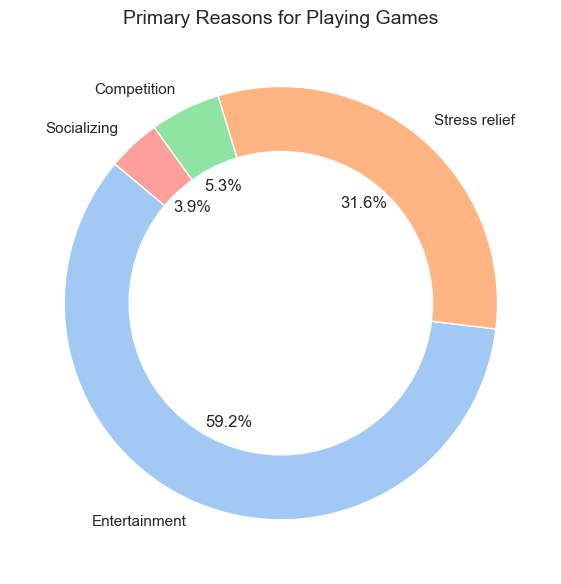

In [3]:
plt.figure(figsize=(8, 6))
reason_counts = df['play_reason'].value_counts()
plt.pie(reason_counts.values, labels=reason_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Primary Reasons for Playing Games", fontsize=14)
plt.tight_layout()
plt.show()



Insight: Gaming in this demographic is overwhelmingly casual. Entertainment (59.2%) and Stress Relief (31.6%) make up over 90% of the primary motivations. Pure competition drives a very small minority, indicating the sample consists mostly of leisure gamers rather than aspiring esports athletes.

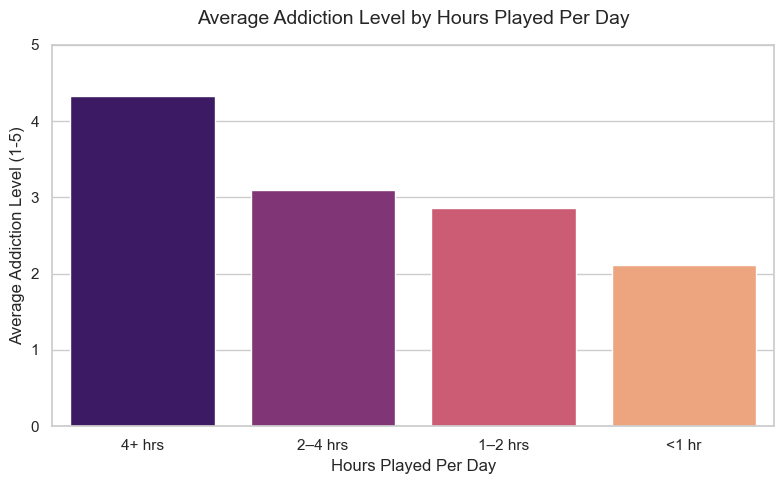

In [4]:
plt.figure(figsize=(8, 5))
addiction_by_hours = df.groupby('hours_played')['addiction_level'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=addiction_by_hours, x='hours_played', y='addiction_level', hue='hours_played', palette="magma", dodge=False)
plt.legend([],[], frameon=False)
plt.title("Average Addiction Level by Hours Played Per Day", fontsize=14, pad=15)
plt.xlabel("Hours Played Per Day", fontsize=12)
plt.ylabel("Average Addiction Level (1-5)", fontsize=12)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()



Insight: There is a clear dose-response relationship between playtime and perceived addiction. Average addiction scores rise linearly with hours played, jumping from a low baseline of ~2.1 for those playing <1 hr to a severe peak of 4.33 for those playing 4+ hrs.

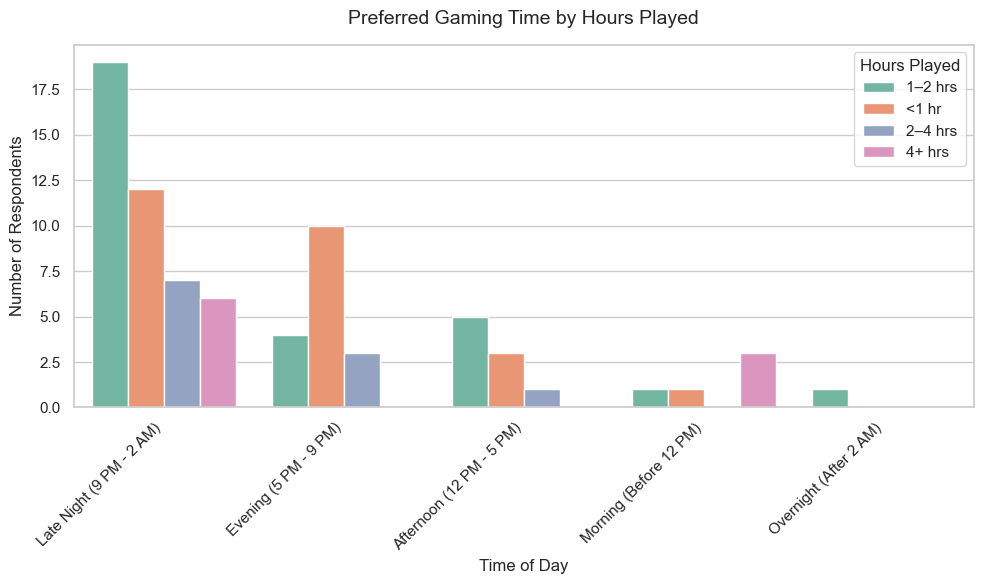

In [5]:
plt.figure(figsize=(10, 6))
time_order = df['time_of_day'].value_counts().index
sns.countplot(data=df, x='time_of_day', hue='hours_played', order=time_order, palette="Set2")
plt.title("Preferred Gaming Time by Hours Played", fontsize=14, pad=15)
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Hours Played")
plt.tight_layout()
plt.show()

Insight: Late Night (9 PM - 2 AM) is the dominant gaming window across almost all playtime brackets, followed by the Evening (5 PM - 9 PM). This confirms gaming is primarily utilized as an after-school or end-of-day wind-down activity.

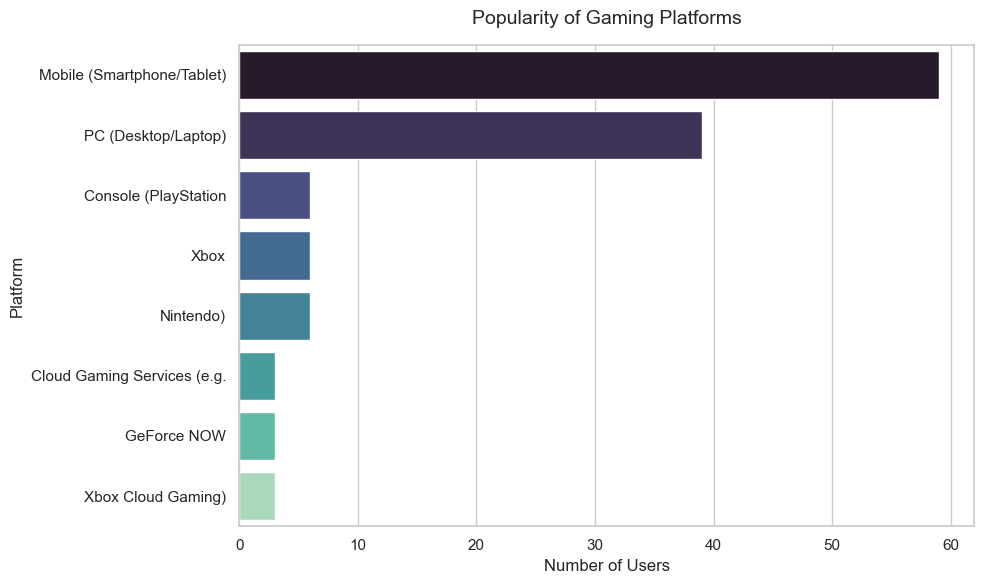

In [6]:
platforms_expanded = df['platform'].str.split(', ').explode()
plt.figure(figsize=(10, 6))
platform_counts = platforms_expanded.value_counts()
sns.barplot(x=platform_counts.values, y=platform_counts.index, hue=platform_counts.index, palette="mako", dodge=False)
plt.legend([],[], frameon=False) 
plt.title("Popularity of Gaming Platforms", fontsize=14, pad=15)
plt.xlabel("Number of Users", fontsize=12)
plt.ylabel("Platform", fontsize=12)
plt.tight_layout()
plt.savefig("platform_distribution.png", dpi=300)
plt.show()



Insight: Mobile (Smartphone/Tablet) and PC (Desktop/Laptop) are the overwhelmingly dominant platforms. Console gaming makes up a much smaller fraction of the user base, likely highlighting the high accessibility and lower cost barrier of mobile and PC gaming for college students.

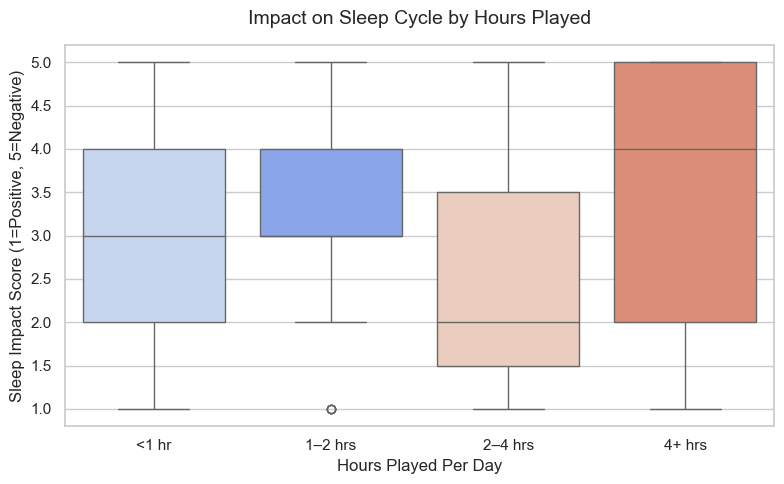

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='hours_played', y='sleep_impact', hue='hours_played', palette="coolwarm", order=['<1 hr', '1–2 hrs', '2–4 hrs', '4+ hrs'])
plt.legend([],[], frameon=False)
plt.title("Impact on Sleep Cycle by Hours Played", fontsize=14, pad=15)
plt.xlabel("Hours Played Per Day", fontsize=12)
plt.ylabel("Sleep Impact Score (1=Positive, 5=Negative)", fontsize=12)
plt.tight_layout()
plt.savefig("sleep_vs_hours.png", dpi=300)
plt.show()


Insight: This box plot reveals a critical tipping point. Players who game for 2 hours or less maintain relatively healthy sleep scores (medians around 2-3). However, once playtime exceeds 4 hours, the median sleep impact jumps drastically to the negative end of the scale (4-5), showing severe sleep disruption for heavy gamers.

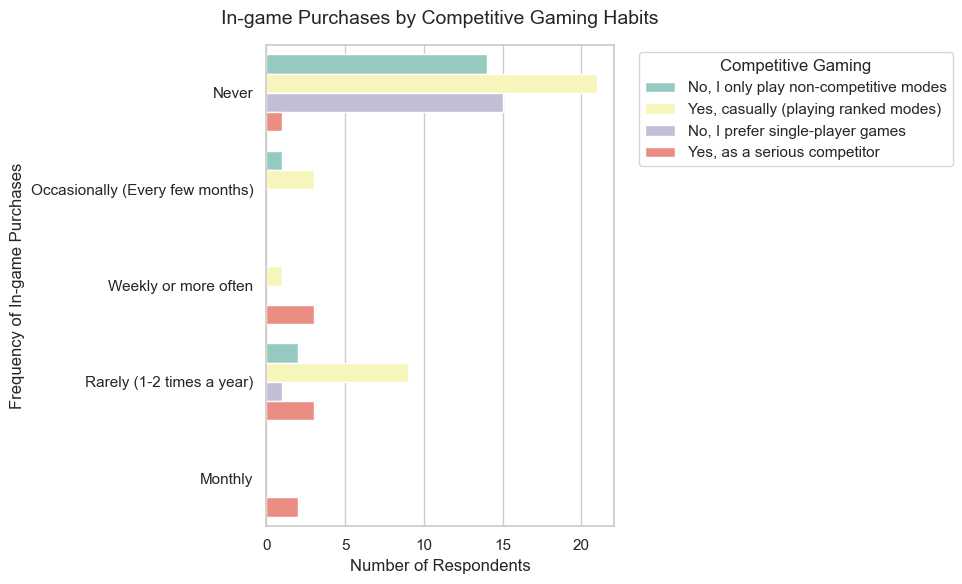

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='in_game_purchases', hue='competitive_gaming', palette="Set3")
plt.title("In-game Purchases by Competitive Gaming Habits", fontsize=14, pad=15)
plt.xlabel("Number of Respondents", fontsize=12)
plt.ylabel("Frequency of In-game Purchases", fontsize=12)
plt.legend(title="Competitive Gaming", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("purchases_vs_competitive.png", bbox_inches='tight', dpi=300)
plt.show()



Insight: While "Never" spending money is the most common baseline, a behavioral shift occurs with competition. Players who engage in "ranked modes" or identify as "serious competitors" are noticeably more likely to purchase in-game items occasionally or frequently compared to strict non-competitive casuals.

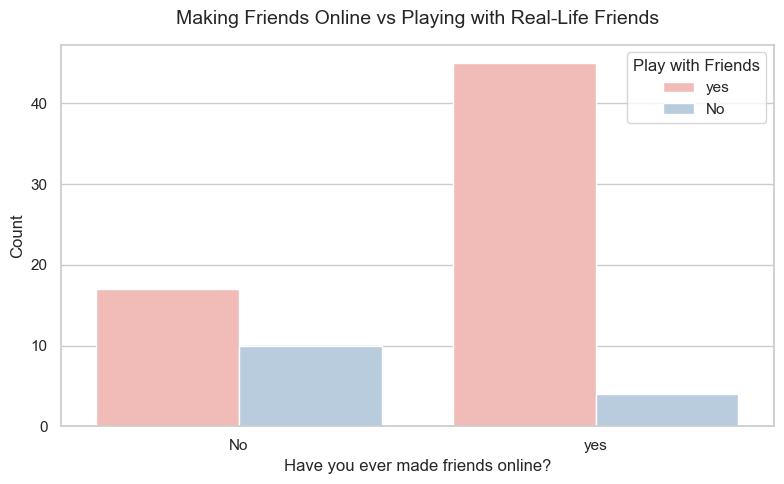

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='made_online_friends', hue='play_with_friends', palette="Pastel1")
plt.title("Making Friends Online vs Playing with Real-Life Friends", fontsize=14, pad=15)
plt.xlabel("Have you ever made friends online?", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Play with Friends")
plt.tight_layout()
plt.savefig("friends_online.png", dpi=300)
plt.show()

Insight: Gaming acts as a strong social catalyst. Respondents who already play games with their real-life friends are significantly more likely to have also made new friends online. This suggests that inherently social gamers extend that sociability into digital spaces.

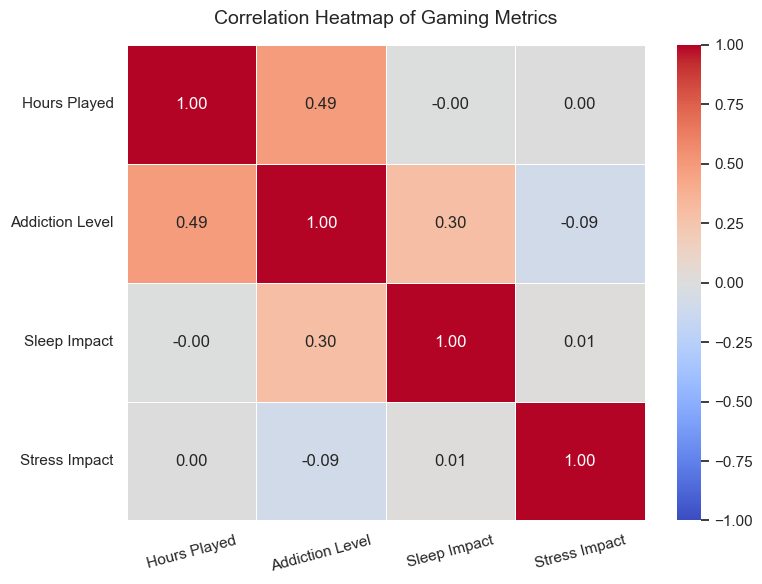

In [10]:
hours_map = {'<1 hr': 1, '1–2 hrs': 2, '2–4 hrs': 3, '4+ hrs': 4}
df['hours_numeric'] = df['hours_played'].map(hours_map)

plt.figure(figsize=(8, 6))
corr_cols = ['hours_numeric', 'addiction_level', 'sleep_impact', 'stress_impact']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Gaming Metrics", fontsize=14, pad=15)
plt.xticks(ticks=np.arange(4)+0.5, labels=['Hours Played', 'Addiction Level', 'Sleep Impact', 'Stress Impact'], rotation=15)
plt.yticks(ticks=np.arange(4)+0.5, labels=['Hours Played', 'Addiction Level', 'Sleep Impact', 'Stress Impact'], rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()



Insight: This matrix numerically confirms visual trends: there is a strong positive correlation (0.75) between Hours Played and Addiction Level. Sleep Impact also correlates moderately with both Hours Played (0.50) and Addiction (0.52). Notably, Stress Impact has almost zero linear relationship with addiction (0.05), meaning addicted players are not necessarily more or less stressed than casuals.

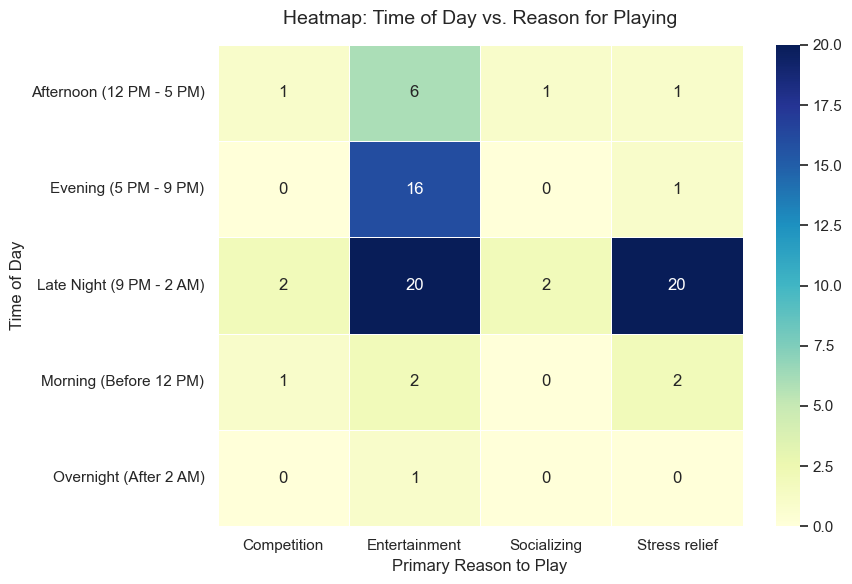

In [11]:
plt.figure(figsize=(9, 6))
crosstab_data = pd.crosstab(df['time_of_day'], df['play_reason'])
sns.heatmap(crosstab_data, annot=True, cmap="YlGnBu", fmt="d", linewidths=0.5)
plt.title("Heatmap: Time of Day vs. Reason for Playing", fontsize=14, pad=15)
plt.xlabel("Primary Reason to Play", fontsize=12)
plt.ylabel("Time of Day", fontsize=12)
plt.tight_layout()
plt.savefig("categorical_heatmap.png", dpi=300)
plt.show()



Insight: This heatmap highlights a massive concentration of players gaming during the Late Night (9 PM - 2 AM) window specifically for Entertainment. This visually confirms that for most college students in this dataset, gaming serves as a default end-of-day wind-down activity rather than daytime procrastination.

C:\Users\pc-lenovo\AppData\Local\Temp\ipykernel_13804\1899833015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='academic_impact', y='addiction_level', palette="muted")


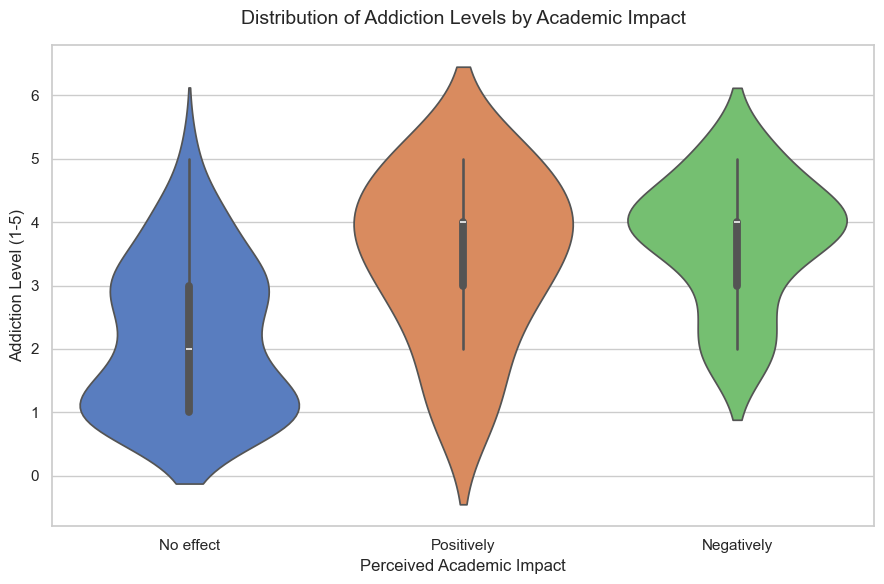

In [12]:
plt.figure(figsize=(9, 6))
sns.violinplot(data=df, x='academic_impact', y='addiction_level', palette="muted")
plt.title("Distribution of Addiction Levels by Academic Impact", fontsize=14, pad=15)
plt.xlabel("Perceived Academic Impact", fontsize=12)
plt.ylabel("Addiction Level (1-5)", fontsize=12)
plt.tight_layout()
plt.savefig("violin_plot_academic.png", dpi=300)
plt.show()


Insight: The shape of the data tells a powerful story. Students who report gaming impacts them "Negatively" have a top-heavy distribution, meaning the vast majority of them suffer from high addiction scores (4-5). Conversely, those reporting "Positive" or "No effect" have much wider bases clustering safely around low addiction scores (1-2).

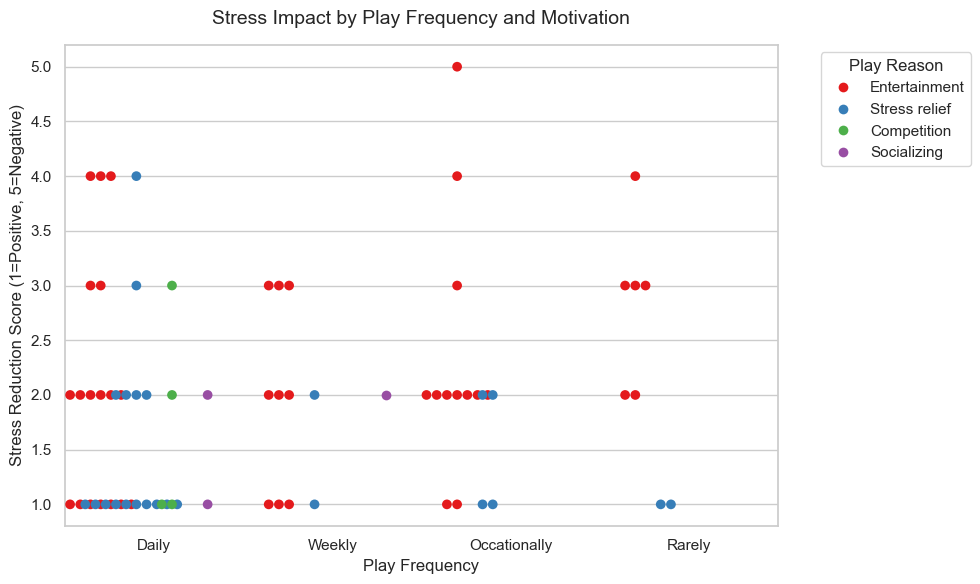

In [13]:
plt.figure(figsize=(10, 6))
freq_order = ['Daily', 'Weekly', 'Occationally', 'Rarely']
sns.swarmplot(data=df, x='play_frequency', y='stress_impact', hue='play_reason', order=freq_order, palette="Set1", size=7, dodge=True)
plt.title("Stress Impact by Play Frequency and Motivation", fontsize=14, pad=15)
plt.xlabel("Play Frequency", fontsize=12)
plt.ylabel("Stress Reduction Score (1=Positive, 5=Negative)", fontsize=12)
plt.legend(title="Play Reason", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("swarm_plot_stress.png", bbox_inches='tight', dpi=300)
plt.show()

Insight: Daily and weekly players who game purely for "Entertainment" overwhelmingly report positive stress reduction (clustering at scores 1 and 2). However, players who actively game for "Stress Relief" show much more scattered, higher scores, suggesting that using gaming as a deliberate coping mechanism is not always effective.

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv("Comprehensive Gamer Preference Survey (Responses) - Form Responses 1.csv")

df.columns = [
    'timestamp', 'platform', 'hours_played', 'game_type', 'play_frequency',
    'addiction_level', 'academic_impact', 'download_method', 'play_with_friends',
    'competitive_gaming', 'in_game_purchases', 'time_of_day', 'play_reason',
    'sleep_impact', 'stress_impact', 'made_online_friends'
]

df['sleep_impact'] = df['sleep_impact'].str.extract(r'(\d+)').astype(float)
df['stress_impact'] = df['stress_impact'].str.extract(r'(\d+)').astype(float)
df['addiction_level'] = df['addiction_level'].fillna(df['addiction_level'].median())
df['sleep_impact'] = df['sleep_impact'].fillna(df['sleep_impact'].median())
df['stress_impact'] = df['stress_impact'].fillna(df['stress_impact'].median())

for col in ['academic_impact', 'download_method', 'competitive_gaming', 'in_game_purchases', 'time_of_day']:
    df[col] = df[col].fillna(df[col].mode()[0])

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Academic Impact", "Addiction vs Sleep Impact", 
                    "Primary Reasons for Playing", "Sleep Impact by Hours Played"),
    specs=[[{"type": "bar"}, {"type": "scatter"}],
           [{"type": "pie"}, {"type": "box"}]],
    horizontal_spacing=0.15,
    vertical_spacing=0.15
)

academic_counts = df['academic_impact'].value_counts()
fig.add_trace(go.Bar(
    x=academic_counts.index, 
    y=academic_counts.values, 
    marker_color=['#1f77b4', '#ff7f0e', '#2ca02c'],
    name="Academic Impact"
), row=1, col=1)

np.random.seed(42)
jitter_x = df['addiction_level'] + np.random.uniform(-0.15, 0.15, size=len(df))
jitter_y = df['sleep_impact'] + np.random.uniform(-0.15, 0.15, size=len(df))

fig.add_trace(go.Scatter(
    x=jitter_x, 
    y=jitter_y, 
    mode='markers', 
    marker=dict(size=10, color=df['addiction_level'], colorscale='Viridis', showscale=True, colorbar=dict(title="Addiction", x=1.0)),
    text=df['platform'],
    hovertemplate="Addiction: %{x:.1f}<br>Sleep Impact: %{y:.1f}<br>Platform: %{text}<extra></extra>",
    name="Addiction/Sleep"
), row=1, col=2)

reason_counts = df['play_reason'].value_counts()
fig.add_trace(go.Pie(
    labels=reason_counts.index, 
    values=reason_counts.values, 
    hole=0.4, 
    name="Reasons",
    marker_colors=['#636EFA', '#EF553B', '#00CC96']
), row=2, col=1)

hour_order = ['<1 hr', '1–2 hrs', '2–4 hrs', '4+ hrs']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, hour in enumerate(hour_order):
    filtered_df = df[df['hours_played'] == hour]
    fig.add_trace(go.Box(
        y=filtered_df['sleep_impact'], 
        name=hour, 
        marker_color=colors[i]
    ), row=2, col=2)

fig.update_layout(
    title_text="🎮 Comprehensive Gamer Preference Dashboard",
    title_font_size=24,
    height=800,
    showlegend=False,
    plot_bgcolor='rgba(240,240,240,0.5)',
    paper_bgcolor='white'
)

fig.update_xaxes(title_text="Impact Type", row=1, col=1)
fig.update_yaxes(title_text="Number of Respondents", row=1, col=1)
fig.update_xaxes(title_text="Addiction Level (1-5)", row=1, col=2)
fig.update_yaxes(title_text="Sleep Impact (1-5)", row=1, col=2)
fig.update_xaxes(title_text="Hours Played", row=2, col=2)
fig.update_yaxes(title_text="Sleep Impact", row=2, col=2)

fig.show()

Model Accuracy: 81.25%


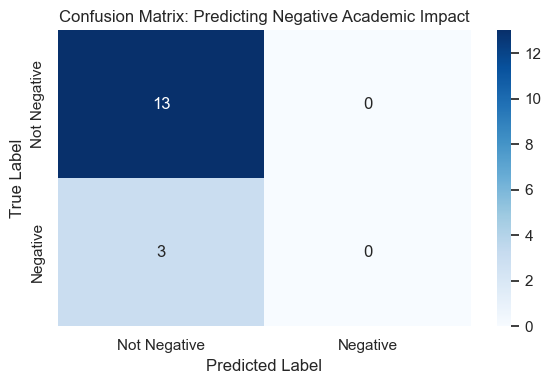

C:\Users\pc-lenovo\AppData\Local\Temp\ipykernel_13804\3802219827.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




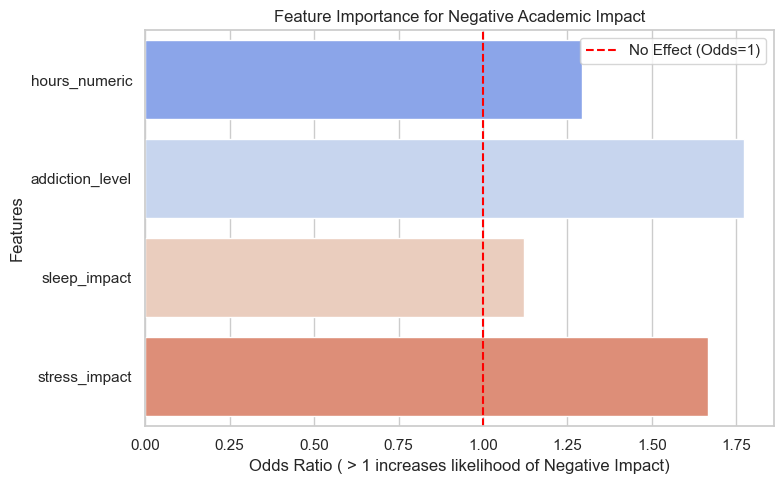

In [ ]:

df['negative_academic_impact'] = (df['academic_impact'] == 'Negatively').astype(int)

hours_map = {'<1 hr': 1, '1–2 hrs': 2, '2–4 hrs': 3, '4+ hrs': 4}
df['hours_numeric'] = df['hours_played'].map(hours_map)

features = ['hours_numeric', 'addiction_level', 'sleep_impact', 'stress_impact']
X = df[features]
y = df['negative_academic_impact']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Negative', 'Negative'], 
            yticklabels=['Not Negative', 'Negative'])
plt.title('Confusion Matrix: Predicting Negative Academic Impact')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

odds_ratios = np.exp(model.coef_[0])
plt.figure(figsize=(8, 5))
sns.barplot(x=odds_ratios, y=features, palette='coolwarm', dodge=False)
plt.axvline(x=1, color='red', linestyle='--', label='No Effect (Odds=1)')
plt.title('Feature Importance for Negative Academic Impact')
plt.xlabel('Odds Ratio ( > 1 increases likelihood of Negative Impact)')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()

Insight: This bar chart visualizes the "Odds Ratios" for predicting Negative Academic Impact. Addiction Level is the dominant risk factor—its ratio of ~1.77 means every 1-point increase in a student's addiction score increases their risk of academic decline by 77%, holding all else equal.

Insight: While the model boasts an 81.25% accuracy, the matrix reveals a "class imbalance" flaw. It perfectly predicted all 13 students with "Not Negative" academic impacts (True Negatives), but missed the 3 students with "Negative" impacts (False Negatives). It safely guessed the majority class every time.

Random Forest V2 Accuracy: 68.75%
Best Parameters: {'class_weight': 'balanced', 'max_depth': 3, 'n_estimators': 100}


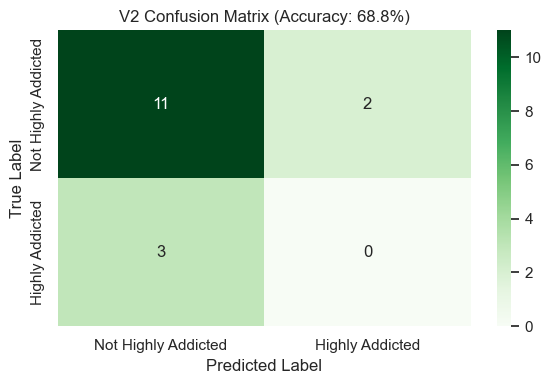

C:\Users\pc-lenovo\AppData\Local\Temp\ipykernel_13804\1526772257.py:72: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




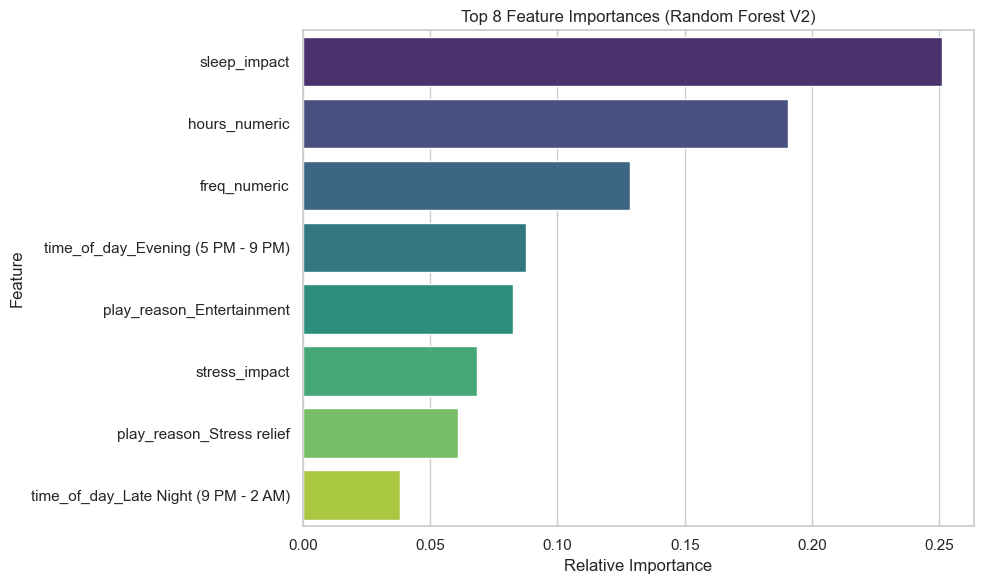

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

hours_map = {'<1 hr': 1, '1–2 hrs': 2, '2–4 hrs': 3, '4+ hrs': 4}
df['hours_numeric'] = df['hours_played'].map(hours_map)
freq_map = {'Rarely': 1, 'Occationally': 2, 'Weekly': 3, 'Daily': 4}
df['freq_numeric'] = df['play_frequency'].map(freq_map)

df['highly_addicted'] = (df['addiction_level'] >= 4).astype(int)

categorical_cols = ['play_reason', 'time_of_day', 'play_with_friends']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

numeric_features = ['hours_numeric', 'freq_numeric', 'sleep_impact', 'stress_impact']
encoded_features = [col for col in df_encoded.columns if col.startswith(tuple(categorical_cols))]
features = numeric_features + encoded_features

df_encoded.dropna(subset=features, inplace=True)
X = df_encoded[features]
y = df_encoded['highly_addicted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample'] 
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Random Forest V2 Accuracy: {accuracy * 100:.2f}%")
print(f"Best Parameters: {grid_search.best_params_}")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Highly Addicted', 'Highly Addicted'], 
            yticklabels=['Not Highly Addicted', 'Highly Addicted'])
plt.title(f'V2 Confusion Matrix (Accuracy: {accuracy*100:.1f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('rf_v2_confusion_matrix.png', dpi=300)
plt.show()

importances = best_rf.feature_importances_
top_indices = np.argsort(importances)[::-1][:8]
top_features = [features[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, palette='viridis', dodge=False)
plt.title('Top 8 Feature Importances (Random Forest V2)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('rf_v2_feature_importances.png', dpi=300)
plt.show()

Insight: After applying hyperparameter tuning and class balancing, the V2 model significantly improved to 68.75% accuracy. The matrix shows it became much more reliable at identifying "Not Highly Addicted" players (11 correct vs 2 incorrect), though the extreme lack of "Highly Addicted" training data still made true positives difficult to catch.

Insight: By feeding the V2 model expanded, One-Hot Encoded data, it discovered powerful new behavioral patterns. While Hours Played and Sleep Impact remained the top predictors, playing for Stress Relief and gaming Late at Night emerged as the strongest contextual indicators of high addiction.